# **Satellite Telemetry Anomaly Detection using LSTM Autoencoder**

- This project simulates satellite telemetry data (temperature, voltage, gyroscope) and detects anomalies using an LSTM Autoencoder. The system identifies abnormal behavior in spacecraft subsystems such as Thermal Control (TCS), Electrical Power (EPS), and Attitude Control (ADCS), enabling early fault detection and health monitoring.

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# **DATA SIMULATION**

-  Satellite Telemetry Simulation
-  Generating synthetic sensor data (Temp, Voltage, Gyro)
-  Injecting realistic anomalies (spike, drop, drift, noise)


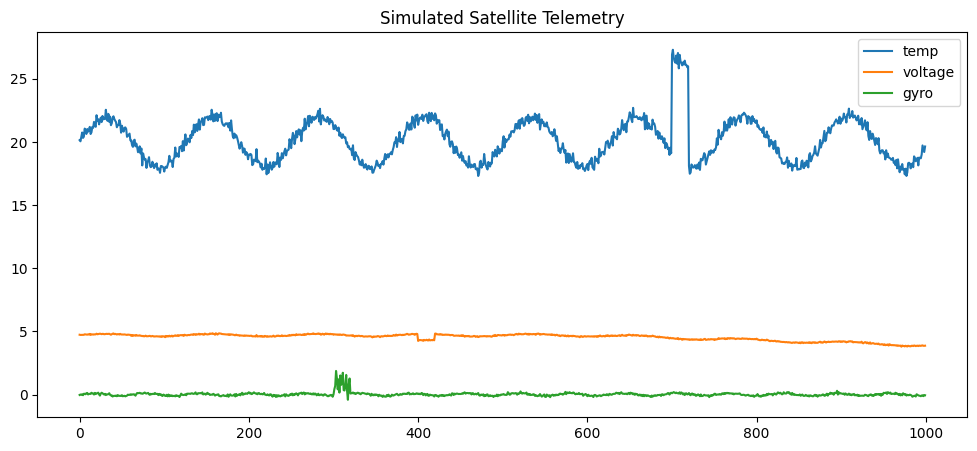

In [79]:
np.random.seed(42)

time_steps = 1000
time = np.linspace(0, 50, time_steps)

# Correlated sensors
temperature = 20 + 2*np.sin(time) + np.random.normal(0, 0.3, time_steps)
voltage = 3.7 + 0.05*temperature + np.random.normal(0, 0.02, time_steps)
gyro = 0.1*np.sin(time*2) + np.random.normal(0, 0.05, time_steps)

# Inject anomalies
temperature[700:720] += 8                      # spike
voltage[400:420] -= 0.5                       # drop
voltage[600:] -= np.linspace(0, 0.8, len(voltage[600:]))  # drift
gyro[300:320] += np.random.normal(1, 0.5, 20)  # noise burst

data = pd.DataFrame({
    "temp": temperature,
    "voltage": voltage,
    "gyro": gyro
})

# Plot
data.plot(figsize=(12,5))
plt.title("Simulated Satellite Telemetry")
plt.show()

# **PREPROCESSING**

-  Normalizing sensor values for stable LSTM training

In [80]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [81]:
def create_sequences(data, seq_length=30):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

seq_length = 30
X = create_sequences(scaled_data, seq_length)

In [82]:
from tensorflow.keras.layers import TimeDistributed, Dense

# **MODEL BUILDING**
-  LSTM Autoencoder Model
-  Learns normal telemetry patterns and reconstructs sequences

In [83]:
timesteps = X.shape[1]
features = X.shape[2]

inputs = Input(shape=(timesteps, features))

encoded = LSTM(64, activation='relu')(inputs)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)

decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 3)          │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,627 (197.76 KB)

 Trainable params: 50,627 (197.76 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history = autoencoder.fit(
    X, X,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.0723 - val_loss: 0.0185
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0196 - val_loss: 0.0121
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0126 - val_loss: 0.0090
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0092 - val_loss: 0.0079
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0079 - val_loss: 0.0066
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0060 - val_loss: 0.0050
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0067 - val_loss: 0.0048


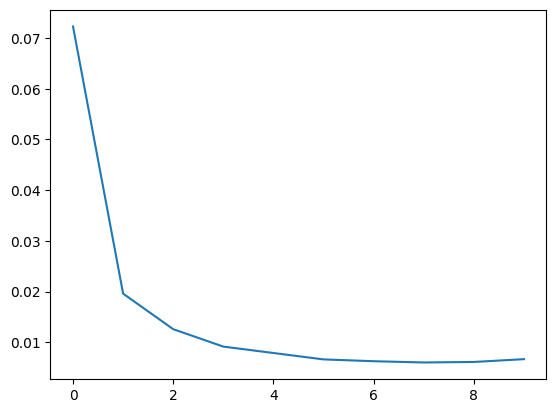

In [98]:
plt.plot(history.history['loss'])

#**RECONSTRUCTION ERROR**
-  Calculating reconstruction error (MSE)
-  Higher error = abnormal pattern

In [85]:
reconstructions = autoencoder.predict(X)

mse = np.mean(np.power(X - reconstructions, 2), axis=(1,2))


threshold = np.percentile(mse, 95)

anomalies = mse > threshold



31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


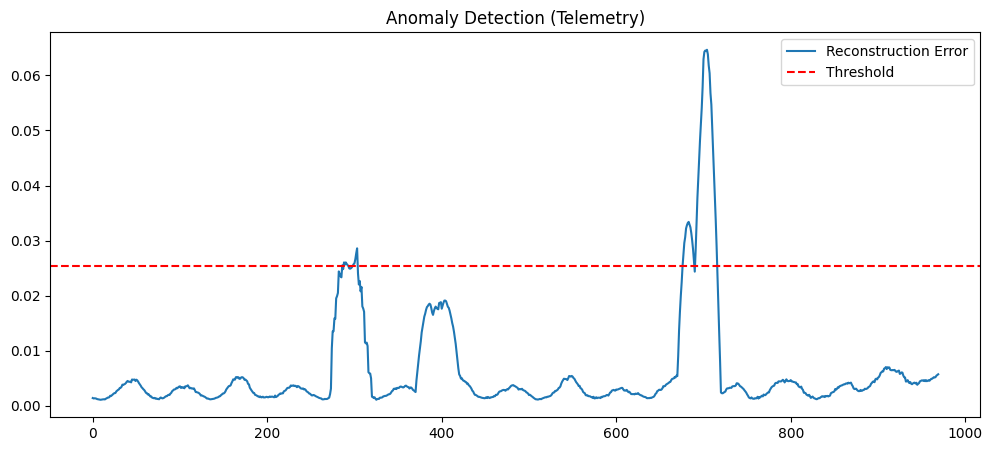

In [86]:
plt.figure(figsize=(12,5))
plt.plot(mse, label="Reconstruction Error")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")

plt.legend()
plt.title("Anomaly Detection (Telemetry)")
plt.show()

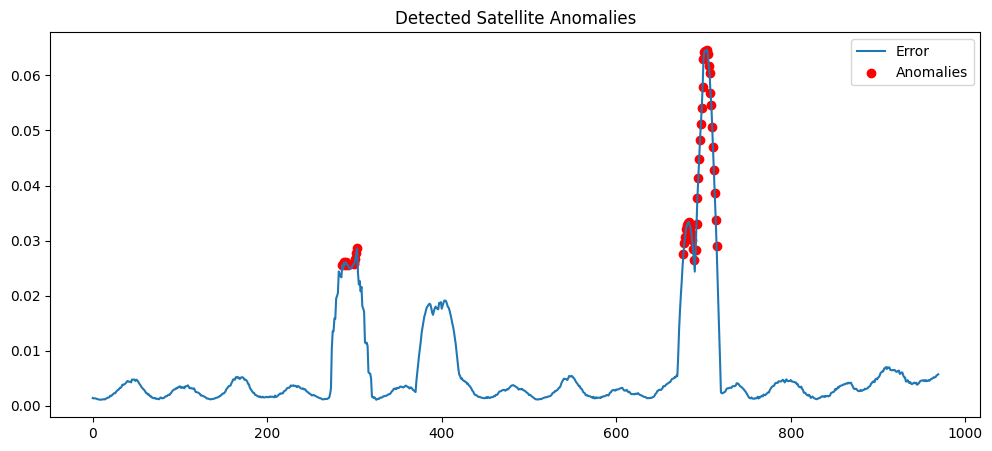

In [87]:
plt.figure(figsize=(12,5))
plt.plot(mse, label="Error")

anomaly_points = np.where(anomalies)[0]
plt.scatter(anomaly_points, mse[anomaly_points], color='red', label="Anomalies")

plt.legend()
plt.title("Detected Satellite Anomalies")
plt.show()

In [88]:
labels = np.zeros(len(mse))

labels[700:720] = 1
labels[400:420] = 1
labels[600:] = 1
labels[300:320] = 1

pred_labels = anomalies.astype(int)

print(classification_report(labels, pred_labels))

              precision    recall  f1-score   support

         0.0       0.60      0.99      0.75       560
         1.0       0.86      0.10      0.18       410

    accuracy                           0.61       970
   macro avg       0.73      0.54      0.46       970
weighted avg       0.71      0.61      0.51       970



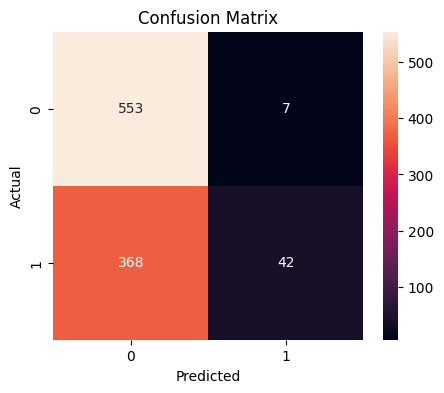

In [89]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(labels, pred_labels)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

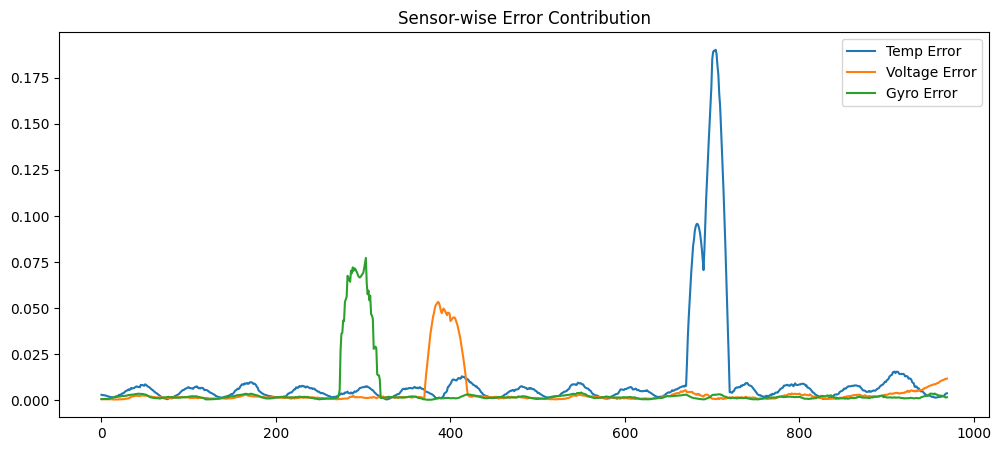

In [90]:
sensor_error = np.mean(np.power(X - reconstructions, 2), axis=1)

plt.figure(figsize=(12,5))
plt.plot(sensor_error[:,0], label="Temp Error")
plt.plot(sensor_error[:,1], label="Voltage Error")
plt.plot(sensor_error[:,2], label="Gyro Error")

plt.legend()
plt.title("Sensor-wise Error Contribution")
plt.show()

In [91]:
subsystem_labels = []

for i in range(len(sensor_error)):
    if sensor_error[i,0] > sensor_error[i,1] and sensor_error[i,0] > sensor_error[i,2]:
        subsystem_labels.append("Thermal Control Subsystem")
    elif sensor_error[i,1] > sensor_error[i,0] and sensor_error[i,1] > sensor_error[i,2]:
        subsystem_labels.append("Thermal Control Subsystem")
    else:
        subsystem_labels.append("Electrical Power Subsystem")

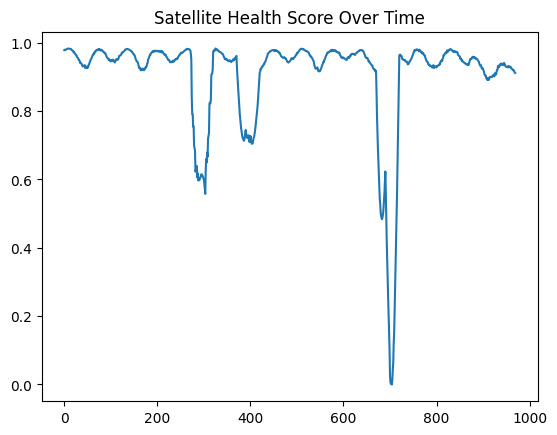

In [92]:
health_score = 1 - (mse / np.max(mse))
plt.plot(health_score)
plt.title("Satellite Health Score Over Time")
plt.show()

In [93]:
prev = -2
for i, val in enumerate(anomalies):
    if val and i != prev + 1:
        print(f"⚠️ ALERT START at timestep {i}: {subsystem_labels[i]}")
    prev = i if val else prev
print("Anomaly timesteps:", np.where(anomalies)[0][:20])

⚠️ ALERT START at timestep 286: Electrical Power Subsystem
⚠️ ALERT START at timestep 288: Electrical Power Subsystem
⚠️ ALERT START at timestep 299: Electrical Power Subsystem
⚠️ ALERT START at timestep 677: Thermal Control Subsystem
⚠️ ALERT START at timestep 691: Thermal Control Subsystem
Anomaly timesteps: [286 288 289 290 291 292 299 300 301 302 303 677 678 679 680 681 682 683
 684 685]


In [94]:
top_idx = np.argsort(mse)[-10:]

print("Top critical anomalies:")
for i in top_idx:
    print(f"Timestep {i} → Error: {mse[i]:.4f} → System: {subsystem_labels[i]}")

Top critical anomalies:
Timestep 708 → Error: 0.0568 → System: Thermal Control Subsystem
Timestep 699 → Error: 0.0579 → System: Thermal Control Subsystem
Timestep 707 → Error: 0.0604 → System: Thermal Control Subsystem
Timestep 706 → Error: 0.0618 → System: Thermal Control Subsystem
Timestep 700 → Error: 0.0629 → System: Thermal Control Subsystem
Timestep 705 → Error: 0.0638 → System: Thermal Control Subsystem
Timestep 701 → Error: 0.0643 → System: Thermal Control Subsystem
Timestep 703 → Error: 0.0644 → System: Thermal Control Subsystem
Timestep 702 → Error: 0.0645 → System: Thermal Control Subsystem
Timestep 704 → Error: 0.0646 → System: Thermal Control Subsystem


In [95]:
print("Total anomalies detected:", np.sum(anomalies))

Total anomalies detected: 49


In [96]:
mse_smooth = pd.Series(mse).rolling(window=5).mean()
mse_smooth = mse_smooth.bfill()

threshold = np.percentile(mse_smooth, 95)
anomalies = mse_smooth > threshold

#**SUBSYSTEM DISTRIBUTION**
- # Subsystem-Level Insights
- # Distribution of anomalies across spacecraft subsystems

In [97]:
print("\n--- FINAL REPORT ---")
print("Total anomalies detected:", np.sum(anomalies))
print("Threshold used:", threshold)
print("Model type: LSTM Autoencoder")
print("Subsystems monitored: TCS, EPS, ADCS")

print("\n--- SUBSYSTEM ANOMALY DISTRIBUTION ---")
for u, c in zip(unique, counts):
    print(f"{u}: {c} anomalies detected")


--- FINAL REPORT ---
Total anomalies detected: 49
Threshold used: 0.025497373112952484
Model type: LSTM Autoencoder
Subsystems monitored: TCS, EPS, ADCS

--- SUBSYSTEM ANOMALY DISTRIBUTION ---
Electrical Power Subsystem: 12 anomalies detected
Thermal Control Subsystem: 37 anomalies detected
